# Four Qubit Chip Design

In [1]:
%reload_ext autoreload
%autoreload 2

## Prerequisite

In [2]:
import os
from collections import OrderedDict

import numpy as np
import pandas as pd
from IPython.display import Image, display
from qiskit_metal import Dict, MetalGUI, designs
from qiskit_metal.qlibrary.qubits.transmon_pocket_cl import TransmonPocketCL
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.launchpad_wb_coupled import (
    LaunchpadWirebondCoupled,
)
from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander

## Four Qubit Design

We will aim for the following parameters on our chip;

- qubit frequency => 4.8, 5, 5.2, 5.4 GHz
- qubit anharmonicity => 300 MHz
- qubit-bus coupling ($g_{q - bus}$) => 80 MHz
- qubit-readout ($\chi_{qc}$ ) => 1 MHz
- bus frequency 
    - Q1 (bus_12, bus_14) => 5.8, 6.0 GHz
    - Q2 (bus_23, bus_12) => 6.2, 5.8 GHz
    - Q3 (bus_34, bus_23) => 6.4, 6.2 GHz
    - Q4 (bus_14, bus_34) => 6.0, 6.4 GHz
- readout frequencies => 6.8, 7, 7.2, 7.4 GHz
- readout Q_external => 2000 ????

In [3]:
design = designs.DesignPlanar()

gui = MetalGUI(design)

In [4]:
design.overwrite_enabled = True

In [5]:
design.variables["cpw_width"] = "10 um"
design.variables["cpw_gap"] = "6 um"
design._chips["main"]["size"]["size_x"] = "9mm"
design._chips["main"]["size"]["size_y"] = "6.5mm"

We need 4 transmons with 3 connection pads each and a chargeline. Let's explore the options of one transmon

In [6]:
TransmonPocketCL.get_template_options(design)

{'pos_x': '0.0um',
 'pos_y': '0.0um',
 'orientation': '0.0',
 'chip': 'main',
 'layer': '1',
 'connection_pads': {},
 '_default_connection_pads': {'pad_gap': '15um',
  'pad_width': '125um',
  'pad_height': '30um',
  'pad_cpw_shift': '5um',
  'pad_cpw_extent': '25um',
  'cpw_width': 'cpw_width',
  'cpw_gap': 'cpw_gap',
  'cpw_extend': '100um',
  'pocket_extent': '5um',
  'pocket_rise': '65um',
  'loc_W': '+1',
  'loc_H': '+1'},
 'pad_gap': '30um',
 'inductor_width': '20um',
 'pad_width': '455um',
 'pad_height': '90um',
 'pocket_width': '650um',
 'pocket_height': '650um',
 'make_CL': True,
 'cl_gap': '6um',
 'cl_width': '10um',
 'cl_length': '20um',
 'cl_ground_gap': '6um',
 'cl_pocket_edge': '0',
 'cl_off_center': '50um',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False,
 'hfss_inductance': '10nH',
 'hfss_capacitance': 0,
 'hfss_resistance': 0,
 'hfss_mesh_kw_jj': 7e-06,
 'q3d_inductance': '10nH',
 'q3d_capacitance': 0,
 

We want to change the `pad_width` for these transmons, as well as define the 3 connection pads and chargeline.

To apply the same modifications to all 4 transmons, we define a single option-dictionary to pass to all transmons at the monent of creation

In [7]:
offset_tm = 69  # we the transmon slightly out of center-line

q1 = TransmonPocketCL(
    design,
    "Q1",
    options=dict(
        pos_x="-2420um",
        pos_y=f"{offset_tm}um",
        orientation="180",
        gds_cell_name="FakeJunction_01",
        cl_off_center="-50um",
        cl_pocket_edge="180",
        connection_pads=dict(
            readout=dict(loc_W=+1, loc_H=-1, pad_width="70um", cpw_extend="50um"),
            bus_12=dict(loc_W=-1, loc_H=-1, pad_width="125um", cpw_extend="50um"),
            bus_14=dict(loc_W=-1, loc_H=+1, pad_width="110um", cpw_extend="50um"),
        ),
    ),
)
q2 = TransmonPocketCL(
    design,
    "Q2",
    options=dict(
        pos_x="0um",
        pos_y="+857.6um",
        orientation="90",
        gds_cell_name="FakeJunction_01",
        cl_off_center="-50um",
        cl_pocket_edge="180",
        connection_pads=dict(
            readout=dict(loc_W=+1, loc_H=-1, pad_width="70um", cpw_extend="50um"),
            bus_23=dict(loc_W=-1, loc_H=-1, pad_width="125um", cpw_extend="50um"),
            bus_12=dict(loc_W=-1, loc_H=+1, pad_width="110um", cpw_extend="50um"),
        ),
    ),
)

q3 = TransmonPocketCL(
    design,
    "Q3",
    options=dict(
        pos_x="+2420um",
        pos_y=f"{offset_tm}um",
        gds_cell_name="FakeJunction_01",
        cl_off_center="-50um",
        cl_pocket_edge="180",
        connection_pads=dict(
            readout=dict(loc_W=+1, loc_H=-1, pad_width="70um", cpw_extend="50um"),
            bus_34=dict(loc_W=-1, loc_H=-1, pad_width="125um", cpw_extend="50um"),
            bus_23=dict(loc_W=-1, loc_H=+1, pad_width="110um", cpw_extend="50um"),
        ),
    ),
)

q4 = TransmonPocketCL(
    design,
    "Q4",
    options=dict(
        pos_x="0um",
        pos_y="-857.6um",
        orientation="270",
        gds_cell_name="FakeJunction_01",
        cl_off_center="-50um",
        cl_pocket_edge="180",
        connection_pads=dict(
            readout=dict(loc_W=+1, loc_H=-1, pad_width="70um", cpw_extend="50um"),
            bus_14=dict(loc_W=-1, loc_H=-1, pad_width="125um", cpw_extend="50um"),
            bus_34=dict(loc_W=-1, loc_H=+1, pad_width="110um", cpw_extend="50um"),
        ),
    ),
)

gui.rebuild()
gui.autoscale()

We can now create the 4 transmons by specifying the desired coordinates and orientations.

Let's now connect the transmons with tranismission lines. We want to have an "exact length" transmission line, so we will use the `RouteMeander`. Let's first observe what are the default options

In [8]:
RouteMeander.get_template_options(design)

{'chip': 'main',
 'layer': '1',
 'pin_inputs': {'start_pin': {'component': '', 'pin': ''},
  'end_pin': {'component': '', 'pin': ''}},
 'fillet': '0',
 'lead': {'start_straight': '0mm',
  'end_straight': '0mm',
  'start_jogged_extension': '',
  'end_jogged_extension': ''},
 'total_length': '7mm',
 'trace_width': 'cpw_width',
 'meander': {'spacing': '200um', 'asymmetry': '0um'},
 'snap': 'true',
 'prevent_short_edges': 'true',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False}

We want to globally override the default lead (straight initial segment leaving the transmon) and the default fillet (corner rounding radius). Let's collect this information in one dictionary

In [9]:
from qiskit_metal.analyses.em.cpw_calculations import guided_wavelength


def find_resonator_length(frequency, line_width, line_gap, N):
    # frequency in GHz
    # line_width/line_gap in um
    # N -> 2 for lambda/2, 4 for lambda/4
    # substrate dimensions and properties already set

    [lambdaG, etfSqrt, q] = guided_wavelength(
        frequency * 10**9,
        line_width * 10**-6,
        line_gap * 10**-6,
        750 * 10**-6,
        200 * 10**-9,
        11.9,
    )
    return str(lambdaG / N * 10**3) + " mm"

In [10]:
q1.pins.keys()

dict_keys(['readout', 'bus_12', 'bus_14', 'Charge_Line'])

In [11]:
bus_12 = find_resonator_length(frequency=5.8, line_width=10, line_gap=6, N=2)
bus_14 = find_resonator_length(frequency=6.0, line_width=10, line_gap=6, N=2)
bus_23 = find_resonator_length(frequency=6.2, line_width=10, line_gap=6, N=2)
bus_34 = find_resonator_length(frequency=6.4, line_width=10, line_gap=6, N=2)

bus_12 = str(round(float(bus_12.split()[0]), 2)) + "mm"
bus_14 = str(round(float(bus_14.split()[0]), 2)) + "mm"
bus_23 = str(round(float(bus_23.split()[0]), 2)) + "mm"
bus_34 = str(round(float(bus_34.split()[0]), 2)) + "mm"

print("bus_12 length: " + bus_12)
print("bus_14 length: " + bus_14)
print("bus_23 length: " + bus_23)
print("bus_34 length: " + bus_34)

bus_12 length: 10.31mm
bus_14 length: 9.97mm
bus_23 length: 9.64mm
bus_34 length: 9.34mm


In [12]:
fillet = "99.99um"
cpw_options = Dict(
    lead=Dict(start_straight="100um", end_straight="250um"), fillet=fillet
)

We then want each transmission line to be connected to different pins and to have different lengths and asymmetry w.r.t their centerline. Let's collect this information in other dictionaries. Before doing that, to manage the dictionaries in a simpler way, we redefine the `RouteMeander` signature by wrapping it into a convenience method named `connect`

In [13]:
def connect(
    cpw_name: str,
    pin1_comp_name: str,
    pin1_comp_pin: str,
    pin2_comp_name: str,
    pin2_comp_pin: str,
    length: str,
    asymmetry="0 um",
):
    """Connect two pins with a CPW."""
    myoptions = Dict(
        pin_inputs=Dict(
            start_pin=Dict(component=pin1_comp_name, pin=pin1_comp_pin),
            end_pin=Dict(component=pin2_comp_name, pin=pin2_comp_pin),
        ),
        total_length=length,
    )
    myoptions.update(cpw_options)
    myoptions.meander.asymmetry = asymmetry
    return RouteMeander(design, cpw_name, myoptions)

We can now proceed and define the meanders following the signature: `connect(cpw_name, pin1_comp_name, pin1_comp_pin, pin2_comp_name, pin2_comp_pin, length, asymmetry)`

In [14]:
asym = 500
cpw1 = connect(
    "cpw1", "Q1", "bus_12", "Q2", "bus_12", bus_12, f"+{asym + 0.75 * offset_tm}um"
)
cpw2 = connect(
    "cpw2", "Q3", "bus_23", "Q2", "bus_23", bus_23, f"-{asym + 0.75 * offset_tm}um"
)
cpw3 = connect(
    "cpw3", "Q3", "bus_34", "Q4", "bus_34", bus_34, f"+{asym - 1.25 * offset_tm}um"
)
cpw4 = connect(
    "cpw4", "Q1", "bus_14", "Q4", "bus_14", bus_14, f"-{asym - 1.25 * offset_tm}um"
)

gui.rebuild()
gui.autoscale()

### Let's now connect the core elements to the launchpads

First we setup the launchpad location and orientation

In [15]:
# V1 - Corners
launch_cl_q1 = LaunchpadWirebond(
    design,
    "Launch_CL_Q1",
    options=dict(pos_x="-3545um", pos_y="-2812um", orientation="90", lead_length="0um"),
)
launch_cl_q2 = LaunchpadWirebond(
    design,
    "Launch_CL_Q2",
    options=dict(pos_x="-3545um", pos_y="2812um", orientation="270", lead_length="0um"),
)
launch_cl_q3 = LaunchpadWirebond(
    design,
    "Launch_CL_Q3",
    options=dict(pos_x="3545um", pos_y="2812um", orientation="270", lead_length="0um"),
)
launch_cl_q4 = LaunchpadWirebond(
    design,
    "Launch_CL_Q4",
    options=dict(pos_x="3545um", pos_y="-2812um", orientation="90", lead_length="0um"),
)

# V2
launch_ro_q1 = LaunchpadWirebondCoupled(
    design,
    "Launch_RO_Q1",
    options=dict(pos_x="-4020um", pos_y="0", orientation="0", lead_length="30um"),
)
launch_ro_q2 = LaunchpadWirebondCoupled(
    design,
    "Launch_RO_Q2",
    options=dict(pos_x="990um", pos_y="2812um", orientation="270", lead_length="30um"),
)
launch_ro_q3 = LaunchpadWirebondCoupled(
    design,
    "Launch_RO_Q3",
    options=dict(pos_x="4020um", pos_y="0", orientation="180", lead_length="30um"),
)
launch_ro_q4 = LaunchpadWirebondCoupled(
    design,
    "Launch_RO_Q4",
    options=dict(pos_x="-990um", pos_y="-2812um", orientation="90", lead_length="30um"),
)

gui.rebuild()
gui.autoscale()

Then we route. First the V2 launchpads - Exchange Coupler Lines to Edges

Connected to the readout resonators of each qubit

Used for dispersive readout — you send a probe tone and measure the reflected/transmitted signal to determine the qubit state without directly measuring it

In [16]:
readout1 = find_resonator_length(frequency=6.8, line_width=10, line_gap=6, N=2)
readout2 = find_resonator_length(frequency=7.0, line_width=10, line_gap=6, N=2)
readout3 = find_resonator_length(frequency=7.2, line_width=10, line_gap=6, N=2)
readout4 = find_resonator_length(frequency=7.4, line_width=10, line_gap=6, N=2)

readout1 = str(round(float(readout1.split()[0]), 2)) + "mm"
readout2 = str(round(float(readout2.split()[0]), 2)) + "mm"
readout3 = str(round(float(readout3.split()[0]), 2)) + "mm"
readout4 = str(round(float(readout4.split()[0]), 2)) + "mm"

print("readout1 length: " + readout1)
print("readout2 length: " + readout2)
print("readout3 length: " + readout3)
print("readout4 length: " + readout4)

readout1 length: 8.79mm
readout2 length: 8.54mm
readout3 length: 8.31mm
readout4 length: 8.08mm


In [17]:
asym = 150
cpw_options = Dict(lead=Dict(start_straight="430um", end_straight="0um"), fillet=fillet)
readout1 = connect(
    "Readout1", "Q1", "readout", "Launch_RO_Q1", "tie", readout1, f"+{asym}um"
)
readout3 = connect(
    "Readout3", "Q3", "readout", "Launch_RO_Q3", "tie", readout3, f"+{asym}um"
)

asym = 200
cpw_options = Dict(lead=Dict(start_straight="535um", end_straight="0um"), fillet=fillet)
readout2 = connect(
    "Readout2", "Q2", "readout", "Launch_RO_Q2", "tie", readout2, f"+{asym}um"
)
readout4 = connect(
    "Readout4", "Q4", "readout", "Launch_RO_Q4", "tie", readout4, f"+{asym}um"
)

gui.rebuild()
gui.autoscale()

Finally we route the V1 launchpads - Charge Lines to Corners

We create the transmission lines between the corner launchpads and the open to grounds

Connected to the charge lines of each qubit

Used for single-qubit control — sending microwave pulses to drive qubit transitions

In [18]:
jogsA_in = OrderedDict()
jogsA_in[0] = ["L", "200um"]

options_charge_line1 = {
    "pin_inputs": {
        "start_pin": {"component": "Q1", "pin": "Charge_Line"},
        "end_pin": {"component": "Launch_CL_Q1", "pin": "tie"},
    },
    "lead": {
        "start_straight": "120um",
        "end_straight": "225um",
        "start_jogged_extension": jogsA_in,
    },
    "fillet": fillet,
}
charge_line1 = RouteAnchors(design, "Charge_Line1", options_charge_line1)

options_charge_line3 = {
    "pin_inputs": {
        "start_pin": {"component": "Q3", "pin": "Charge_Line"},
        "end_pin": {"component": "Launch_CL_Q3", "pin": "tie"},
    },
    "lead": {
        "start_straight": "120um",
        "end_straight": "225um",
        "start_jogged_extension": jogsA_in,
    },
    "fillet": fillet,
}
charge_line3 = RouteAnchors(design, "Charge_Line3", options_charge_line3)

gui.rebuild()
gui.autoscale()

In [19]:
jogsB_in = OrderedDict()
jogsB_in[0] = ["L", "300um"]

anchors2c = OrderedDict()
anchors2c[0] = np.array([-2, 2.5])

options_charge_line2 = {
    "pin_inputs": {
        "start_pin": {"component": "Q2", "pin": "Charge_Line"},
        "end_pin": {"component": "Launch_CL_Q2", "pin": "tie"},
    },
    "lead": {
        "start_straight": "400um",
        "end_straight": "100um",
        "start_jogged_extension": jogsB_in,
    },
    "anchors": anchors2c,
    "fillet": fillet,
}

charge_line2 = RouteAnchors(design, "Charge_Line2", options_charge_line2)

anchors4c = OrderedDict()
anchors4c[0] = np.array([2, -2.5])

options_charge_line4 = {
    "pin_inputs": {
        "start_pin": {"component": "Q4", "pin": "Charge_Line"},
        "end_pin": {"component": "Launch_CL_Q4", "pin": "tie"},
    },
    "lead": {
        "start_straight": "400um",
        "end_straight": "225um",
        "start_jogged_extension": jogsB_in,
    },
    "anchors": anchors4c,
    "fillet": fillet,
}

charge_line4 = RouteAnchors(design, "Charge_Line4", options_charge_line4)

gui.rebuild()
gui.autoscale()

In [20]:
# Get a list of all the qcomponents in QDesign and then zoom on them.
all_component_names = design.components.keys()

gui.zoom_on_components(all_component_names)

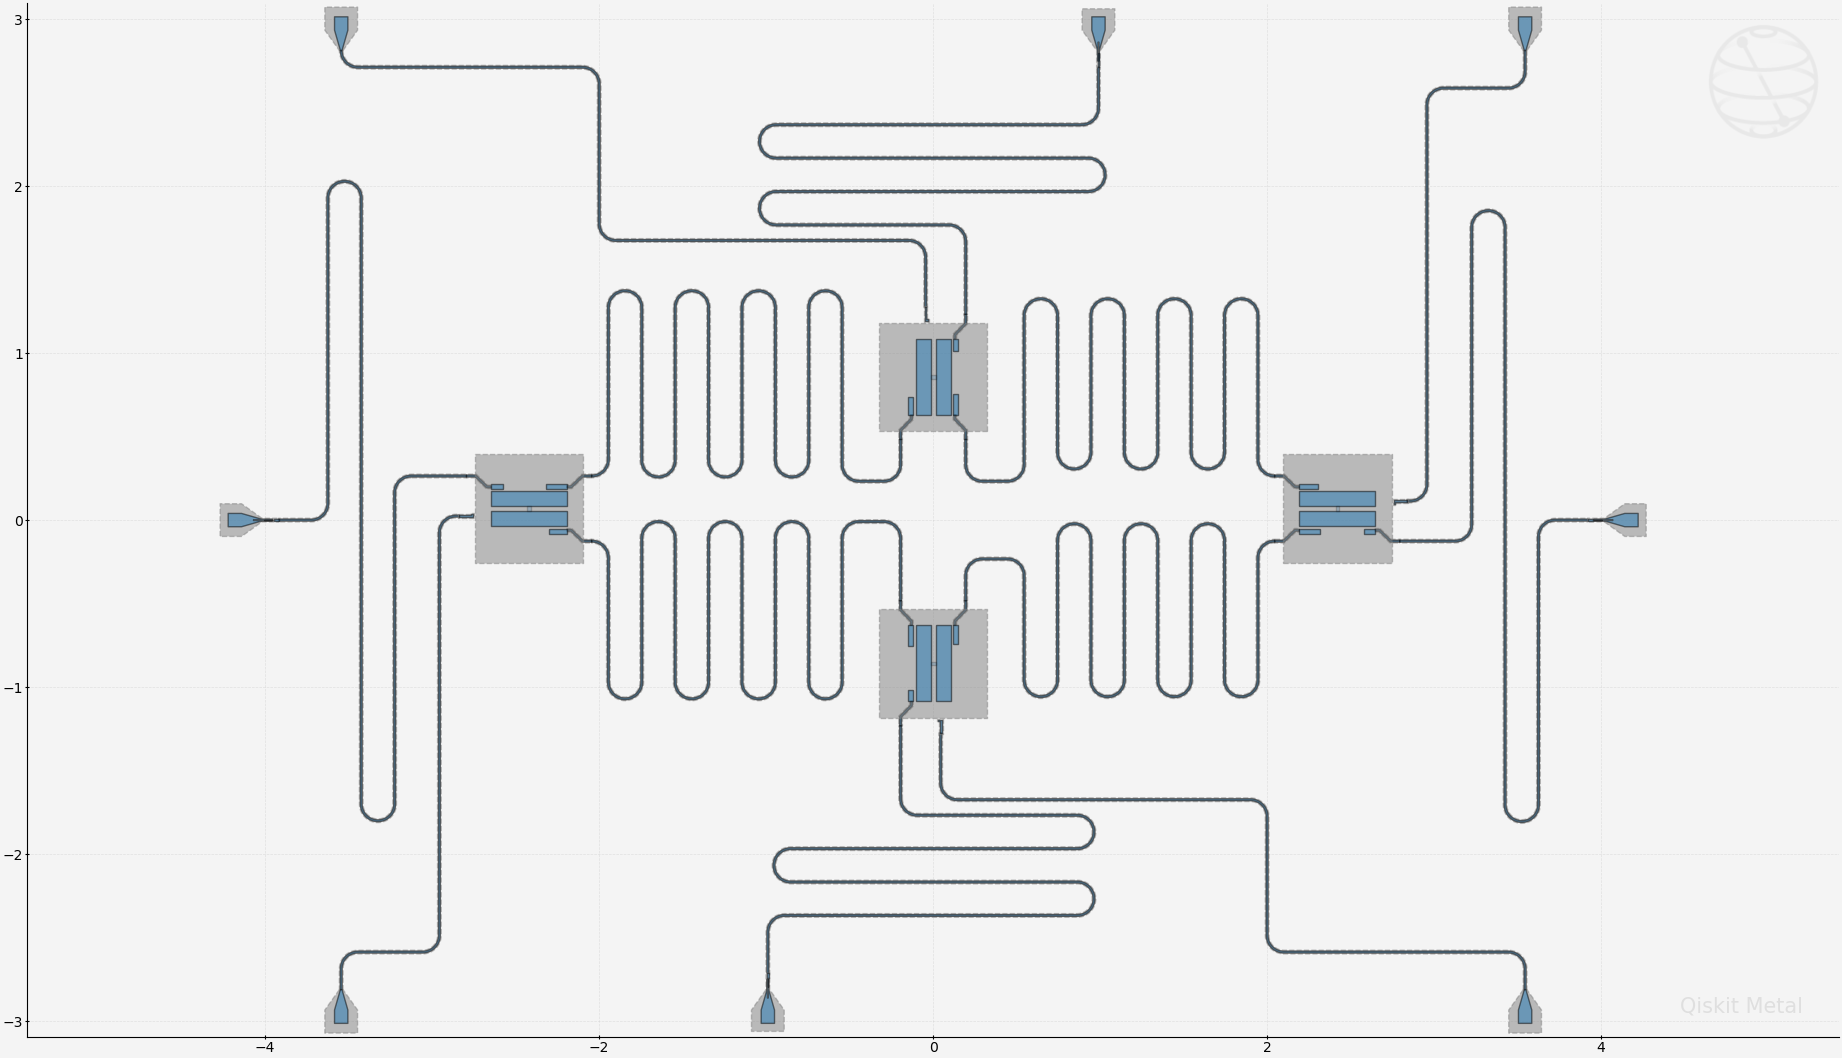

In [21]:
gui.figure.savefig("shot.png")

_disp_ops = dict(width=500)
display(Image("shot.png", **_disp_ops))

![Chip design](shot.png)

In [22]:
# # Closing the Qiskit Metal GUI
# gui.main_window.close()

In [23]:
# with open("four_qubit_chip_design_v2.py", "w") as f:
#     f.write(design.to_python_script())

In [ ]:
# %run "./four_qubit_chip_design_v2.py"
# list(design.components.keys())

# Simulation and Analysis

All the qubit parameters can initially be tuned via a capacitance matrix and the lumped oscillator method (LOM).

As a reminder, our target parameters are (approximately):
- qubit frequency => 4.8, 5, 5.2, 5.4 GHz
- qubit anharmonicity => 300 MHz
- qubit-bus coupling ($g_{q - bus}$) => 80 MHz
- qubit-readout ($\chi_{qc}$ ) => 1 MHz
- bus frequency 
    - Q1 (bus_12, bus_14) => 5.8, 6.0 GHz
    - Q2 (bus_23, bus_12) => 6.2, 5.8 GHz
    - Q3 (bus_34, bus_23) => 6.4, 6.2 GHz
    - Q4 (bus_14, bus_34) => 6.0, 6.4 GHz
- readout frequencies => 6.8, 7, 7.2, 7.4 GHz
- readout Q_external => 2000 ????

## Qubits and Lumped Oscillator Model (LOM)

## Main-Pad Sweep — Tuning Anharmonicity (α)

LOM on the isolated qubit (Q3D), same as the χ/g connection-pad sweep, but here we vary the
**main island geometry** to tune EC and therefore the anharmonicity α ≈ −EC toward the
target **|α| ≈ 300 MHz**.

We sweep one parameter at a time, resetting to the design default (`pad_width=455um`,
`pad_height=90um`, `pad_gap=30um`) before the next:

- `pad_width`  → larger width → more island capacitance → smaller EC → smaller |α|
- `pad_height` → larger height → more island capacitance → smaller EC → smaller |α|
- `pad_gap`    → gap between the two islands (where the junction sits); changes how the
  islands couple → shifts EC

`Lj` is held fixed (14.745 nH): EC/α depend only on geometry, while `Lj` only moves `fQ`.
Each sweep is saved to `results/main_pad_anharmonicity_sweep/` and plotted as |α|/EC vs
geometry.

In [24]:
from qiskit_metal.analyses.quantization import LOManalysis

lom_4qb = LOManalysis(design, "q3d")

In [25]:
lom_4qb.sim.setup.percent_error = 0.1
lom_4qb.sim.setup.max_passes = 20

lom_4qb.setup.freq_readout = 6.8  # GHz — Q1 readout target
lom_4qb.setup.freq_bus = [5.8, 6.0]  # GHz — bus_12, bus_14 tar

OPEN_TERMINATIONS = [("Q1", "readout"), ("Q1", "bus_12"), ("Q1", "bus_14")]

In [ ]:
for q in [q1, q2, q3, q4]:
    q.options.make_CL = False  # hide charge line from Q3D nets
design.rebuild()

# Design defaults — each parameter is reset to its default before the next sweep
MAIN_PAD_DEFAULTS = {"pad_width": "455um", "pad_height": "90um", "pad_gap": "30um"}

# ── Sweep ranges (one parameter at a time; island stays inside pocket = 650 µm)
main_pad_width_sweep = ["250um", "300um", "350um", "400um", "455um", "500um", "550um"]
main_pad_height_sweep = ["50um", "70um", "90um", "110um", "130um", "150um"]
main_pad_gap_sweep = ["10um", "20um", "30um", "40um", "50um", "60um"]


def sweep_main_pad(param, values):
    """Sweep one top-level main-pad option on Q1, recording anharmonicity metrics."""
    res = {}
    for val in values:
        q1.options[param] = val
        design.rebuild()
        lom_4qb.run(components=["Q1"], open_terminations=OPEN_TERMINATIONS)
        lo = lom_4qb.lumped_oscillator
        res[val] = {
            "fQ": lo["fQ"],
            "EC_MHz": lo["EC"],
            "EJ": lo["EJ"],
            "alpha_MHz": lo["alpha"],
        }
    q1.options[param] = MAIN_PAD_DEFAULTS[param]  # reset to design value
    design.rebuild()
    return res


res_main_pad_width = sweep_main_pad("pad_width", main_pad_width_sweep)
res_main_pad_height = sweep_main_pad("pad_height", main_pad_height_sweep)
res_main_pad_gap = sweep_main_pad("pad_gap", main_pad_gap_sweep)

INFO 11:24AM [connect_project]: Connecting to Ansys Desktop API...
INFO 11:24AM [load_ansys_project]: 	Opened Ansys App
INFO 11:24AM [load_ansys_project]: 	Opened Ansys Desktop v2021.1.0
INFO 11:24AM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/giann/Documents/Ansoft/
	Project:   Project29
INFO 11:24AM [connect_design]: No active design found (or error getting active design).
INFO 11:24AM [connect]: 	 Connected to project "Project29". No design detected
INFO 11:24AM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
WARNING 11:24AM [connect_setup]: 	No design setup detected.
WARNING 11:24AM [connect_setup]: 	Creating Q3D default setup.
INFO 11:24AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 11:24AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 11:24AM [analyze]: Analyzing setup Setup
INFO 11:26AM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\T

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 6.628853 [GHz]
EC 466.948268 [MHz]
EJ 13.616300 [GHz]
alpha -569.972845 [MHz]
dispersion 994.742752 [KHz]
Lq 11.995161 [nH]
Cq 41.482600 [fF]
T1 1.307698 [us]

**Coupling Properties**

tCqbus1 3.471008 [fF]
gbus1_in_MHz 72.457666 [MHz]
χ_bus1 -47.218528 [MHz]
1/T1bus1 118794.238553 [Hz]
T1bus1 1.339753 [us]

tCqbus2 5.438869 [fF]
gbus2_in_MHz 96.789090 [MHz]
χ_bus2 -49.841784 [MHz]
1/T1bus2 899.913854 [Hz]
T1bus2 176.855754 [us]

tCqbus3 -5.956483 [fF]
gbus3_in_MHz -109.693943 [MHz]
χ_bus3 -370.545011 [MHz]
1/T1bus3 2011.999566 [Hz]
T1bus3 79.102871 [us]
Bus-Bus Couplings
gbus1_2 7.922274 [MHz]
gbus1_3 5.061408 [MHz]
gbus2_3 6.849188 [MHz]


INFO 11:26AM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
INFO 11:26AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 11:26AM [analyze]: Analyzing setup Setup
INFO 11:27AM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmp8t_adj0z.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 11:27AM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmptchrxrgn.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 11:27AM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmphlo22yk0.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 11:27AM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmp2ii10mto.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 50000000

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 6.227182 [GHz]
EC 407.637594 [MHz]
EJ 13.616300 [GHz]
alpha -488.473500 [MHz]
dispersion 357.954957 [KHz]
Lq 11.995161 [nH]
Cq 47.518257 [fF]
T1 6.942664 [us]

**Coupling Properties**

tCqbus1 3.589856 [fF]
gbus1_in_MHz 67.257454 [MHz]
χ_bus1 -7.296497 [MHz]
1/T1bus1 8568.392542 [Hz]
T1bus1 18.574656 [us]

tCqbus2 5.576666 [fF]
gbus2_in_MHz 89.064255 [MHz]
χ_bus2 295.927702 [MHz]
1/T1bus2 2703.481416 [Hz]
T1bus2 58.870367 [us]

tCqbus3 -5.947726 [fF]
gbus3_in_MHz -98.290174 [MHz]
χ_bus3 158.932329 [MHz]
1/T1bus3 11652.314506 [Hz]
T1bus3 13.658655 [us]
Bus-Bus Couplings
gbus1_2 6.084894 [MHz]
gbus1_3 4.573025 [MHz]
gbus2_3 6.202490 [MHz]


INFO 11:27AM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
INFO 11:27AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 11:27AM [analyze]: Analyzing setup Setup
INFO 11:29AM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpqpb0rwmv.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 11:29AM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpe81q8lv4.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 11:29AM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpme40jj60.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 11:29AM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmp6maovop3.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 50000000

...

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 5.481091 [GHz]
EC 309.794381 [MHz]
EJ 13.616300 [GHz]
alpha -360.084566 [MHz]
dispersion 35.695496 [KHz]
Lq 11.995161 [nH]
Cq 62.526080 [fF]
T1 31.013324 [us]

**Coupling Properties**

tCqbus1 3.701323 [fF]
gbus1_in_MHz 55.871796 [MHz]
χ_bus1 -1.030566 [MHz]
1/T1bus1 972.265507 [Hz]
T1bus1 163.694939 [us]

tCqbus2 5.746739 [fF]
gbus2_in_MHz 73.937576 [MHz]
χ_bus2 -18.213600 [MHz]
1/T1bus2 2943.863112 [Hz]
T1bus2 54.063296 [us]

tCqbus3 -5.811137 [fF]
gbus3_in_MHz -77.359554 [MHz]
χ_bus3 -9.482757 [MHz]
1/T1bus3 1215.696156 [Hz]
T1bus3 130.916712 [us]
Bus-Bus Couplings
gbus1_2 3.473503 [MHz]
gbus1_3 3.055654 [MHz]
gbus2_3 4.194019 [MHz]


INFO 11:54AM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
INFO 11:54AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 11:54AM [analyze]: Analyzing setup Setup
INFO 11:55AM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpiidue6jv.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 11:55AM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmp32cta1yd.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 11:55AM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmptodwc7py.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 11:55AM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmppmef7h5r.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 50000000

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 5.599028 [GHz]
EC 324.230738 [MHz]
EJ 13.616300 [GHz]
alpha -378.579504 [MHz]
dispersion 53.578495 [KHz]
Lq 11.995161 [nH]
Cq 59.742109 [fF]
T1 13.390897 [us]

**Coupling Properties**

tCqbus1 3.744427 [fF]
gbus1_in_MHz 58.576789 [MHz]
χ_bus1 -1.386962 [MHz]
1/T1bus1 1319.485257 [Hz]
T1bus1 120.618963 [us]

tCqbus2 5.802077 [fF]
gbus2_in_MHz 77.362753 [MHz]
χ_bus2 -38.942768 [MHz]
1/T1bus2 8294.149517 [Hz]
T1bus2 19.188820 [us]

tCqbus3 -5.857766 [fF]
gbus3_in_MHz -80.814631 [MHz]
χ_bus3 -15.858080 [MHz]
1/T1bus3 2271.673934 [Hz]
T1bus3 70.060646 [us]
Bus-Bus Couplings
gbus1_2 3.420006 [MHz]
gbus1_3 3.005468 [MHz]
gbus2_3 4.102850 [MHz]


INFO 11:55AM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
INFO 11:56AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 11:56AM [analyze]: Analyzing setup Setup
INFO 11:57AM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmp39m85sf4.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 11:57AM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmprepwdmds.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 11:57AM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpgh4syi52.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 11:57AM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpkh6d4u78.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 50000000

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 5.696157 [GHz]
EC 336.405431 [MHz]
EJ 13.616300 [GHz]
alpha -394.294746 [MHz]
dispersion 73.903150 [KHz]
Lq 11.995161 [nH]
Cq 57.580010 [fF]
T1 3.972738 [us]

**Coupling Properties**

tCqbus1 3.777431 [fF]
gbus1_in_MHz 60.829013 [MHz]
χ_bus1 -1.783761 [MHz]
1/T1bus1 1716.273746 [Hz]
T1bus1 92.732843 [us]

tCqbus2 5.847582 [fF]
gbus2_in_MHz 80.259834 [MHz]
χ_bus2 -98.241621 [MHz]
1/T1bus2 34024.083039 [Hz]
T1bus2 4.677714 [us]

tCqbus3 -5.895042 [fF]
gbus3_in_MHz -83.717944 [MHz]
χ_bus3 -26.097180 [MHz]
1/T1bus3 4321.421824 [Hz]
T1bus3 36.829301 [us]
Bus-Bus Couplings
gbus1_2 3.362832 [MHz]
gbus1_3 2.952742 [MHz]
gbus2_3 4.014465 [MHz]


In [31]:
RESULTS_DIR = "results/main_pad_anharmonicity_sweep"
os.makedirs(RESULTS_DIR, exist_ok=True)

sweep_results = {
    "pad_width": (res_main_pad_width, "pad_width"),
    "pad_height": (res_main_pad_height, "pad_height"),
    "pad_gap": (res_main_pad_gap, "pad_gap"),
}

dfs = {}
for key, (res, index_name) in sweep_results.items():
    df = pd.DataFrame(res).T
    df.index.name = index_name
    df.to_csv(f"{RESULTS_DIR}/Q1_main_{key}_sweep.csv")
    dfs[key] = df
    print(f"Saved {RESULTS_DIR}/Q1_main_{key}_sweep.csv  ({len(df)} rows)")

Saved results/main_pad_anharmonicity_sweep/Q1_main_pad_width_sweep.csv  (7 rows)
Saved results/main_pad_anharmonicity_sweep/Q1_main_pad_height_sweep.csv  (6 rows)
Saved results/main_pad_anharmonicity_sweep/Q1_main_pad_gap_sweep.csv  (6 rows)


In [26]:
RESULTS_DIR = "results/main_pad_anharmonicity_sweep"

dfs = {}
for key in ["pad_width", "pad_height", "pad_gap"]:
    path = f"{RESULTS_DIR}/Q1_main_{key}_sweep.csv"
    df = pd.read_csv(path, index_col=0)
    dfs[key] = df
    print(f"Loaded {path}  ({len(df)} rows)")

Loaded results/main_pad_anharmonicity_sweep/Q1_main_pad_width_sweep.csv  (7 rows)
Loaded results/main_pad_anharmonicity_sweep/Q1_main_pad_height_sweep.csv  (6 rows)
Loaded results/main_pad_anharmonicity_sweep/Q1_main_pad_gap_sweep.csv  (6 rows)


In [ ]:
import matplotlib.pyplot as plt

ALPHA_TARGET_MHZ = 300.0


def _um(index):
    return [float(v.replace("um", "")) for v in index]


panels = [
    ("pad_width", "Main pad width"),
    ("pad_height", "Main pad height"),
    ("pad_gap", "Main pad gap"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex="col")
for col, (key, label) in enumerate(panels):
    df = dfs[key]
    x = _um(df.index)

    ax_a = axes[0, col]
    ax_a.plot(x, df["alpha_MHz"].abs(), "o-", color="tab:purple")
    ax_a.axhline(
        ALPHA_TARGET_MHZ,
        color="tab:red",
        ls="--",
        lw=1,
        label=f"target |α| = {ALPHA_TARGET_MHZ:.0f} MHz",
    )
    ax_a.set_title(label)
    ax_a.grid(alpha=0.3)

    ax_ec = axes[1, col]
    ax_ec.plot(x, df["EC_MHz"], "s-", color="tab:orange")
    ax_ec.set_xlabel(f"{label} (µm)")
    ax_ec.grid(alpha=0.3)

axes[0, 0].set_ylabel("|α| (MHz)")
axes[1, 0].set_ylabel("EC (MHz)")
axes[0, 0].legend()
fig.suptitle(
    "Q1 main pad — anharmonicity |α| (target ≈ 300 MHz) and EC vs pad geometry"
)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/Q1_main_pad_anharmonicity_sweeps.png", dpi=150)
plt.show()

In [ ]:
dfs["pad_width"]

,fQ,EC_MHz,EJ,alpha_MHz
pad_width,,,,
250um,6.628853,466.948268,13.6163,-569.972845
300um,6.227182,407.637594,13.6163,-488.473500
350um,5.888697,361.311843,13.6163,-426.785358
400um,5.605157,324.991281,13.6163,-379.558052
455um,5.334915,292.423001,13.6163,-338.028083
500um,5.136927,269.802056,13.6163,-309.627571
550um,4.936532,247.952309,13.6163,-282.536939


## EJ and Lj Targets — pad_width = 550 µm

**EC = 247,95 MHz** (same for all qubits, set by pad geometry)  
**|α| ≈ 282 MHz** (same for all qubits)

| Qubit | Target fQ (GHz) | EJ (GHz) | Lj (nH) | EJ/EC |
|-------|----------------|----------|---------|-------|
| Q1    | 4.8            | 11.086   | 14.745  | 37.9  |
| Q2    | 5.0            | 11.974   | 13.652  | 40.9  |
| Q3    | 5.2            | 12.896   | 12.676  | 44.1  |
| Q4    | 5.4            | 13.852   | 11.801  | 47.4  |

### Formula used

$$f_Q \approx \sqrt{8 E_J E_C} - E_C$$

$$E_J = \frac{(f_Q + E_C)^2}{8 E_C}$$

$$L_j = \frac{(\Phi_0 / 2\pi)^2}{E_J h}$$

where $\Phi_0 = 2.068 \times 10^{-15}$ Wb.

> **Note:** Bus resonator frequencies are set to [6.8, 7.0, 7.2, 7.4] GHz in the LOM setup.  


In [26]:
import numpy as np
from scipy.constants import e, h

# EC_MHz = sweep_data['350um']['variables']['lumped_oscillator']['EC']
EC_MHz = 247.952308539829
EC = EC_MHz * 1e6  # Hz
Phi0 = h / (2 * e)

target_fQ_GHz = [4.8, 5, 5.2, 5.4]

rows = []
for fQ_GHz in target_fQ_GHz:
    fQ = fQ_GHz * 1e9
    EJ = (fQ + EC) ** 2 / (8 * EC)
    Lj = (Phi0 / (2 * np.pi)) ** 2 / (EJ * h)
    rows.append(
        {
            "Qubit": f"Q{target_fQ_GHz.index(fQ_GHz) + 1}",
            "fQ (GHz)": round(fQ_GHz, 1),
            "EJ (GHz)": round(EJ / 1e9, 3),
            "Lj (nH)": round(Lj * 1e9, 3),
            "EJ/EC": round(EJ / EC, 1),
        }
    )

df = pd.DataFrame(rows)
print(f"EC  = {EC_MHz:.3f} MHz  (pad_width = 550um)")
print()
print(df.to_string(index=False))

EC  = 247.952 MHz  (pad_width = 550um)

Qubit  fQ (GHz)  EJ (GHz)  Lj (nH)  EJ/EC
   Q1       4.8    12.846   12.725   51.8
   Q2       5.0    13.884   11.773   56.0
   Q3       5.2    14.963   10.925   60.3
   Q4       5.4    16.081   10.165   64.9


In [27]:
optimal_pad_width = "550um"

for q in [q1, q2, q3, q4]:
    q.options.make_CL = False
    q.options.pad_width = optimal_pad_width
gui.rebuild()

In [28]:
lom_4qb.setup.junctions.Lj = 12.725

In [32]:
lom_4qb.run(
    components=["Q1"],
    open_terminations=OPEN_TERMINATIONS,
)

INFO 01:30PM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
INFO 01:30PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 01:30PM [analyze]: Analyzing setup Setup
INFO 01:32PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpx0himggs.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 01:32PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmp4d4oaxtz.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 01:32PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmp7866hqva.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 01:32PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpuw7ue41w.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 50000000

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 4.785786 [GHz]
EC 247.950065 [MHz]
EJ 12.840519 [GHz]
alpha -283.918217 [MHz]
dispersion 7.174638 [KHz]
Lq 12.719869 [nH]
Cq 78.121488 [fF]
T1 314.609010 [us]

**Coupling Properties**

tCqbus1 3.538586 [fF]
gbus1_in_MHz 44.260230 [MHz]
χ_bus1 -0.248804 [MHz]
1/T1bus1 224.099211 [Hz]
T1bus1 710.198588 [us]

tCqbus2 5.596054 [fF]
gbus2_in_MHz 59.653466 [MHz]
χ_bus2 -1.553308 [MHz]
1/T1bus2 164.043890 [Hz]
T1bus2 970.197323 [us]

tCqbus3 -5.495134 [fF]
gbus3_in_MHz -60.610485 [MHz]
χ_bus3 -1.165178 [MHz]
1/T1bus3 117.738606 [Hz]
T1bus3 1351.765138 [us]
Bus-Bus Couplings
gbus1_2 2.547103 [MHz]
gbus1_3 2.296722 [MHz]
gbus2_3 3.252550 [MHz]


,fQ,EC,EJ,alpha,dispersion,gbus,chi_in_MHz,χr MHz,gr MHz
1,5.162759,291.413686,12.840519,-338.637303,32.909459,"[36.73491649865401, 57.5088524045225, -47.2819...","[-0.2890932083297212, -3.621161358487097, -1.5...",0.289093,36.734916
2,5.092018,282.95154,12.840519,-327.87219,25.163826,"[41.19049456735086, 56.81731024894265, -57.527...","[-0.32805250626409244, -2.904923291515029, -1....",0.328053,41.190495
3,5.008625,273.158717,12.840519,-315.481957,18.15863,"[43.178677222966826, 55.011530626562006, -57.7...","[-0.32035673233454004, -2.196742331773965, -1....",0.320357,43.178677
4,4.948044,266.168018,12.840519,-306.681258,14.226657,"[42.42270988737666, 55.22888600761636, -56.962...","[-0.28433612174233136, -1.9120022786469804, -1...",0.284336,42.422710
5,4.895747,260.216125,12.840519,-299.217208,11.467504,"[42.70503893766959, 56.45914452346739, -57.775...","[-0.26828957845917684, -1.7700667391210503, -1...",0.268290,42.705039
6,4.864421,256.68747,12.840519,-294.804557,10.055422,"[43.34957703966529, 57.44266814230732, -58.373...","[-0.2650058610249005, -1.7076925194487322, -1....",0.265006,43.349577
7,4.839779,253.93096,12.840519,-291.363953,9.056931,"[43.27347303973208, 57.77416826232129, -58.853...","[-0.25549932833171185, -1.6361242027145704, -1...",0.255499,43.273473
8,4.827983,252.617368,12.840519,-289.726354,8.611358,"[43.22554071814394, 58.18272723117203, -59.144...","[-0.25095386661032526, -1.61726696257086, -1.2...",0.250954,43.225541
9,4.815045,251.181116,12.840519,-287.937311,8.145483,"[43.5751043506159, 58.79638181343072, -59.6267...","[-0.25067919160762214, -1.6060525727567447, -1...",0.250679,43.575104
10,4.805866,250.164931,12.840519,-286.672444,7.828872,"[43.8018090406146, 58.7774490917519, -59.75782...","[-0.2502296631687442, -1.5737374366403254, -1....",0.250230,43.801809


In [33]:
lom_4qb.plot_convergence()
lom_4qb.plot_convergence_chi()

INFO 01:39PM [hfss_report_full_convergence]: Creating report for variation 0


Design "Design_q3d" info:
	# eigenmodes    0
	# variations    1


In [34]:
lom_4qb.sim.capacitance_matrix

,bus_12_connector_pad_Q1,bus_14_connector_pad_Q1,ground_main_plane,pad_bot_Q1,pad_top_Q1,readout_connector_pad_Q1
bus_12_connector_pad_Q1,40.55572,-0.17081,-25.32541,-12.99124,-1.31316,-0.08156
bus_14_connector_pad_Q1,-0.17081,38.39148,-24.63547,-1.18202,-11.73350,-0.04029
ground_main_plane,-25.32541,-24.63547,229.14847,-48.73572,-52.57291,-22.73397
pad_bot_Q1,-12.99124,-1.18202,-48.73572,116.36822,-41.71615,-8.32166
pad_top_Q1,-1.31316,-11.73350,-52.57291,-41.71615,111.86798,-0.93017
readout_connector_pad_Q1,-0.08156,-0.04029,-22.73397,-8.32166,-0.93017,32.60505


In [35]:
lom_4qb.lumped_oscillator

{'fQ': 4.785785568554974,
 'EC': 247.9500652908984,
 'EJ': 12.840518673758416,
 'alpha': -283.9182168075662,
 'dispersion': 7.174637697219849,
 'gbus': array([ 44.2602299 ,  59.65346568, -60.61048518]),
 'chi_in_MHz': array([-0.24880409, -1.55330783, -1.16517775])}

### Simulation also for connection pads on the qubits should be made
LOM analysis is specifically for the qubit, it cannot be used for the resonator!
- q1.options.connection_pads.readout.pad_gap
- q1.options.connection_pads.readout.pad_width
- q1.options.connection_pads.bus_01.pad_width
- q1.options.connection_pads.bus_02.pad_width

The relationships:

- Larger pad_width on connection pad → stronger coupling → higher g → higher χ
- Smaller pad_gap on connection pad → coupling pad closer to island → stronger coupling

## Connection Pad Sweep — Tuning χ and g

LOM on the isolated qubit (Q3D). The resonator is NOT simulated — its frequency
is an input (`freq_readout`, `freq_bus`). We use the known target values.

Sweep 1: `connection_pads.readout.pad_width` → tune χ_readout toward −1 MHz  
Sweep 2: `connection_pads.bus_12.pad_width` → tune g_bus toward 80 MHz

In [ ]:
import numpy as np
import pandas as pd

optimal_pad_width = "550um"

# ── Setup: Q1 targets ───────────────────────────────────────────────────────
lom_4qb.setup.freq_readout = 6.8  # GHz — Q1 readout target
lom_4qb.setup.freq_bus = [5.8, 6.0]  # GHz — bus_12, bus_14 targets
lom_4qb.setup.junctions.Lj = 12.725  # nH  — Q1 targeting fQ = 4.8 GHz

for q in [q1, q2, q3, q4]:
    q.options.make_CL = False  # hide charge line from Q3D nets
    q.options.pad_width = optimal_pad_width
design.rebuild()

OPEN_TERMINATIONS = [("Q1", "readout"), ("Q1", "bus_12"), ("Q1", "bus_14")]

# ── Sweep 1: readout connection pad width ───────────────────────────────────
readout_pad_width_sweep = [
    "50um",
    "60um",
    "70um",  # current/default
    "80um",
    "90um",
    "100um",
    "110um",
    "125um",
    "135um",
    "145um",
    "155um",
    "165um",
    "175um",
    "185um",
    "195um",
    "205um",
    "215um",
    "225um",
]
res_readout_pad_width = {}

# ── Sweep 2: readout connection pad gap ─────────────────────────────────────
readout_pad_gap_sweep = [
    "2um",
    "5um",
    "8um",
    "10um",
    "12um",
    "15um",  # current/default
    "18um",
    "22um",
    "26um",
    "30um",
]
res_readout_pad_gap = {}

# ── Sweep 3: readout connection pad height ──────────────────────────────────
readout_pad_height_sweep = [
    "15um",
    "20um",
    "25um",
    "30um",  # current/default
    "35um",
    "40um",
    "50um",
    "60um",
]
res_readout_pad_height = {}

for pw in readout_pad_width_sweep:
    q1.options.connection_pads.readout.pad_width = pw
    design.rebuild()
    lom_4qb.run(components=["Q1"], open_terminations=OPEN_TERMINATIONS)
    lo = lom_4qb.lumped_oscillator
    res_readout_pad_width[pw] = {
        "fQ": lo["fQ"],
        "EC_MHz": lo["EC"],
        "chi_readout_MHz": lo["chi_in_MHz"][0],  # index 0 = readout mode
        "gbus_readout_MHz": lo["gbus"][0],
        "alpha_MHz": lo["alpha"],
    }

q1.options.connection_pads.readout.pad_width = "70um"  # reset to design value
design.rebuild()
for pg in readout_pad_gap_sweep:
    q1.options.connection_pads.readout.pad_gap = pg
    design.rebuild()
    lom_4qb.run(components=["Q1"], open_terminations=OPEN_TERMINATIONS)
    lo = lom_4qb.lumped_oscillator
    res_readout_pad_gap[pg] = {
        "fQ": lo["fQ"],
        "EC_MHz": lo["EC"],
        "chi_readout_MHz": lo["chi_in_MHz"][0],  # index 0 = readout mode
        "gbus_readout_MHz": lo["gbus"][0],
        "alpha_MHz": lo["alpha"],
    }

q1.options.connection_pads.readout.pad_gap = "15um"  # reset to design value
design.rebuild()
for ph in readout_pad_height_sweep:
    q1.options.connection_pads.readout.pad_height = ph
    design.rebuild()
    lom_4qb.run(components=["Q1"], open_terminations=OPEN_TERMINATIONS)
    lo = lom_4qb.lumped_oscillator
    res_readout_pad_height[ph] = {
        "fQ": lo["fQ"],
        "EC_MHz": lo["EC"],
        "chi_readout_MHz": lo["chi_in_MHz"][0],  # index 0 = readout mode
        "gbus_readout_MHz": lo["gbus"][0],
        "alpha_MHz": lo["alpha"],
    }

q1.options.connection_pads.readout.pad_height = "30um"  # reset to design value
design.rebuild()

INFO 09:07PM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
INFO 09:07PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 09:07PM [analyze]: Analyzing setup Setup
INFO 09:09PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmplxvz9g0q.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 09:09PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmphagnu3mm.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 09:09PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpc5bu_396.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 09:09PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpjfxcivrc.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 50000000

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 4.791484 [GHz]
EC 248.577427 [MHz]
EJ 12.840519 [GHz]
alpha -284.697982 [MHz]
dispersion 7.355076 [KHz]
Lq 12.719869 [nH]
Cq 77.924325 [fF]
T1 366.532593 [us]

**Coupling Properties**

tCqbus1 2.846903 [fF]
gbus1_in_MHz 35.697813 [MHz]
χ_bus1 -0.163071 [MHz]
1/T1bus1 146.812592 [Hz]
T1bus1 1084.068747 [us]

tCqbus2 5.648530 [fF]
gbus2_in_MHz 60.331453 [MHz]
χ_bus2 -1.608075 [MHz]
1/T1bus2 169.916673 [Hz]
T1bus2 936.664665 [us]

tCqbus3 -5.449196 [fF]
gbus3_in_MHz -60.222069 [MHz]
χ_bus3 -1.162542 [MHz]
1/T1bus3 117.488445 [Hz]
T1bus3 1354.643373 [us]
Bus-Bus Couplings
gbus1_2 2.079603 [MHz]
gbus1_3 1.876515 [MHz]
gbus2_3 3.279749 [MHz]


INFO 09:09PM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
INFO 09:09PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 09:09PM [analyze]: Analyzing setup Setup
INFO 09:11PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpi5vmo31r.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 09:11PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpvvi7i3b9.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 09:11PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpaxiwb5ob.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 09:11PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmppbyci1ac.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 50000000

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 4.788603 [GHz]
EC 248.260126 [MHz]
EJ 12.840519 [GHz]
alpha -284.303564 [MHz]
dispersion 7.263342 [KHz]
Lq 12.719869 [nH]
Cq 78.023919 [fF]
T1 339.877432 [us]

**Coupling Properties**

tCqbus1 3.194411 [fF]
gbus1_in_MHz 40.004785 [MHz]
χ_bus1 -0.204018 [MHz]
1/T1bus1 183.718349 [Hz]
T1bus1 866.298572 [us]

tCqbus2 5.622384 [fF]
gbus2_in_MHz 59.992498 [MHz]
χ_bus2 -1.580392 [MHz]
1/T1bus2 166.946998 [Hz]
T1bus2 953.326177 [us]

tCqbus3 -5.472186 [fF]
gbus3_in_MHz -60.416081 [MHz]
χ_bus3 -1.163790 [MHz]
1/T1bus3 117.606237 [Hz]
T1bus3 1353.286587 [us]
Bus-Bus Couplings
gbus1_2 2.313808 [MHz]
gbus1_3 2.087383 [MHz]
gbus2_3 3.266213 [MHz]


INFO 09:11PM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
INFO 09:11PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 09:11PM [analyze]: Analyzing setup Setup
INFO 09:13PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpjn7cwxae.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 09:13PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpp4s49k4h.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 09:13PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpo06j1ppr.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 09:13PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpgjqt6fsc.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 50000000

...

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 4.785081 [GHz]
EC 247.872508 [MHz]
EJ 12.840519 [GHz]
alpha -283.821840 [MHz]
dispersion 7.152593 [KHz]
Lq 12.719869 [nH]
Cq 78.145932 [fF]
T1 300.963414 [us]

**Coupling Properties**

tCqbus1 3.724398 [fF]
gbus1_in_MHz 46.564956 [MHz]
χ_bus1 -0.275134 [MHz]
1/T1bus1 247.829118 [Hz]
T1bus1 642.196303 [us]

tCqbus2 5.586157 [fF]
gbus2_in_MHz 59.533360 [MHz]
χ_bus2 -1.544759 [MHz]
1/T1bus2 163.130750 [Hz]
T1bus2 975.628099 [us]

tCqbus3 -5.502915 [fF]
gbus3_in_MHz -60.681486 [MHz]
χ_bus3 -1.166382 [MHz]
1/T1bus3 117.858373 [Hz]
T1bus3 1350.391487 [us]
Bus-Bus Couplings
gbus1_2 2.712532 [MHz]
gbus1_3 2.439956 [MHz]
gbus2_3 3.246313 [MHz]


INFO 10:13PM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
INFO 10:13PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 10:13PM [analyze]: Analyzing setup Setup
INFO 10:15PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmp4oi_pl_2.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 10:15PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpv6hhzrso.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 10:15PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpbq7c2ty5.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 10:15PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpqfbn6az6.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 50000000

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 4.784575 [GHz]
EC 247.816906 [MHz]
EJ 12.840519 [GHz]
alpha -283.752747 [MHz]
dispersion 7.136825 [KHz]
Lq 12.719869 [nH]
Cq 78.163465 [fF]
T1 291.238080 [us]

**Coupling Properties**

tCqbus1 3.860876 [fF]
gbus1_in_MHz 48.256290 [MHz]
χ_bus1 -0.295288 [MHz]
1/T1bus1 265.992913 [Hz]
T1bus1 598.342794 [us]

tCqbus2 5.580856 [fF]
gbus2_in_MHz 59.466347 [MHz]
χ_bus2 -1.539641 [MHz]
1/T1bus2 162.582870 [Hz]
T1bus2 978.915815 [us]

tCqbus3 -5.507498 [fF]
gbus3_in_MHz -60.721362 [MHz]
χ_bus3 -1.166820 [MHz]
1/T1bus3 117.901322 [Hz]
T1bus3 1349.899562 [us]
Bus-Bus Couplings
gbus1_2 2.848213 [MHz]
gbus1_3 2.555146 [MHz]
gbus2_3 3.242236 [MHz]


INFO 10:15PM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
INFO 10:15PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 10:15PM [analyze]: Analyzing setup Setup
INFO 10:17PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpxo0ytm6j.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 10:17PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpxluoh3oe.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 10:17PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpzbpjbt2f.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 10:17PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmp17xn303p.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 50000000

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 4.784280 [GHz]
EC 247.784400 [MHz]
EJ 12.840519 [GHz]
alpha -283.712356 [MHz]
dispersion 7.127619 [KHz]
Lq 12.719869 [nH]
Cq 78.173719 [fF]
T1 283.067609 [us]

**Coupling Properties**

tCqbus1 3.977942 [fF]
gbus1_in_MHz 49.708397 [MHz]
χ_bus1 -0.313204 [MHz]
1/T1bus1 282.138828 [Hz]
T1bus1 564.101525 [us]

tCqbus2 5.575575 [fF]
gbus2_in_MHz 59.403889 [MHz]
χ_bus2 -1.535451 [MHz]
1/T1bus2 162.136149 [Hz]
T1bus2 981.612948 [us]

tCqbus3 -5.511331 [fF]
gbus3_in_MHz -60.757360 [MHz]
χ_bus3 -1.167564 [MHz]
1/T1bus3 117.975658 [Hz]
T1bus3 1349.048993 [us]
Bus-Bus Couplings
gbus1_2 2.970509 [MHz]
gbus1_3 2.658085 [MHz]
gbus2_3 3.238425 [MHz]


In [69]:
RESULTS_DIR = "results/readout_pad_sweep"
os.makedirs(RESULTS_DIR, exist_ok=True)

sweep_results = {
    "pad_width": (res_readout_pad_width, "pad_width"),
    "pad_gap": (res_readout_pad_gap, "pad_gap"),
    "pad_height": (res_readout_pad_height, "pad_height"),
}

dfs = {}
for key, (res, index_name) in sweep_results.items():
    df = pd.DataFrame(res).T
    df.index.name = index_name
    df.to_csv(f"{RESULTS_DIR}/Q1_readout_{key}_sweep.csv")
    dfs[key] = df
    print(f"Saved {RESULTS_DIR}/Q1_readout_{key}_sweep.csv  ({len(df)} rows)")

Saved results/readout_pad_sweep/Q1_readout_pad_width_sweep.csv  (18 rows)
Saved results/readout_pad_sweep/Q1_readout_pad_gap_sweep.csv  (10 rows)
Saved results/readout_pad_sweep/Q1_readout_pad_height_sweep.csv  (8 rows)


In [36]:
RESULTS_DIR = "results/readout_pad_sweep"

dfs = {}
for key in ["pad_width", "pad_height", "pad_gap"]:
    path = f"{RESULTS_DIR}/Q1_readout_{key}_sweep.csv"
    df = pd.read_csv(path, index_col=0)
    dfs[key] = df
    print(f"Loaded {path}  ({len(df)} rows)")

Loaded results/readout_pad_sweep/Q1_readout_pad_width_sweep.csv  (18 rows)
Loaded results/readout_pad_sweep/Q1_readout_pad_height_sweep.csv  (8 rows)
Loaded results/readout_pad_sweep/Q1_readout_pad_gap_sweep.csv  (10 rows)


In [ ]:
import matplotlib.pyplot as plt

CHI_TARGET_MHZ = -1.0


def _um(index):
    return [float(v.replace("um", "")) for v in index]


panels = [
    ("pad_width", "Pad width"),
    ("pad_gap", "Pad gap"),
    ("pad_height", "Pad height"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex="col")
for col, (key, label) in enumerate(panels):
    df = dfs[key]
    x = _um(df.index)

    ax_chi = axes[0, col]
    ax_chi.plot(x, df["chi_readout_MHz"], "o-", color="tab:blue")
    ax_chi.axhline(
        CHI_TARGET_MHZ,
        color="tab:red",
        ls="--",
        lw=1,
        label=f"target χ = {CHI_TARGET_MHZ} MHz",
    )
    ax_chi.set_title(label)
    ax_chi.grid(alpha=0.3)

    ax_g = axes[1, col]
    ax_g.plot(x, df["gbus_readout_MHz"], "s-", color="tab:green")
    ax_g.set_xlabel(f"{label} (µm)")
    ax_g.grid(alpha=0.3)

axes[0, 0].set_ylabel("χ readout (MHz)")
axes[1, 0].set_ylabel("g readout (MHz)")
axes[0, 0].legend()
fig.suptitle("Q1 readout — χ (target ≈ −1 MHz) and g vs connection-pad geometry")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/Q1_readout_pad_geometry_sweeps.png", dpi=150)
plt.show()

In [ ]:
dfs["pad_width"]
optimal_readout_pad_width = "185um"

,fQ,EC_MHz,chi_readout_MHz,gbus_readout_MHz,alpha_MHz
pad_width,,,,,
50um,4.791484,248.577427,-0.163071,35.697813,-284.697982
60um,4.788603,248.260126,-0.204018,40.004785,-284.303564
70um,4.785806,247.952309,-0.248815,44.260564,-283.921004
80um,4.782909,247.633655,-0.298390,48.562421,-283.525052
90um,4.779930,247.306315,-0.351345,52.799179,-283.118385
100um,4.777198,247.006301,-0.408422,57.028943,-282.745737
110um,4.774147,246.671412,-0.467931,61.165042,-282.329848
125um,4.770072,246.224668,-0.563711,67.313620,-281.775179
135um,4.767298,245.920738,-0.630737,71.332925,-281.397911


## Bus Connection-Pad Sweep — Tuning g (target ≈ 80 MHz)

LOM on isolated Q1 (Q3D), same setup as the readout sweep, but now we tune the two **bus**
connection pads so each qubit–bus coupling g lands near **80 MHz**.

Mode indices follow `OPEN_TERMINATIONS = [readout, bus_12, bus_14]`:
- **bus_12 → index 1** (5.8 GHz bus)
- **bus_14 → index 2** (6.0 GHz bus)

Levers: larger `pad_width` → stronger coupling → higher g; smaller `pad_gap` → pad closer to
the island → higher g; `pad_height` is a finer lever. We sweep width/gap/height one at a time
(resetting to defaults between), with the readout pad fixed at its tuned 185 µm.

In [29]:
optimal_pad_width = "550um"
optimal_readout_pad_width = "185um"
# ── Tuned-state setup ───────────────────────────────────────────────────────
lom_4qb.setup.freq_readout = 6.8  # GHz
lom_4qb.setup.freq_bus = [5.8, 6.0]  # GHz — bus_12, bus_14
lom_4qb.setup.junctions.Lj = 12.725  # nH  — Q1

for q in [q1, q2, q3, q4]:
    q.options.make_CL = False
    q.options.pad_width = optimal_pad_width  # fixed main pad (sets EC)
# put the design in its χ-tuned state so bus g is measured against the real readout pad
q1.options.connection_pads.readout.pad_width = optimal_readout_pad_width  # "185um"
design.rebuild()

OPEN_TERMINATIONS = [("Q1", "readout"), ("Q1", "bus_12"), ("Q1", "bus_14")]

# Connection-pad defaults to reset to between sweeps
BUS_DEFAULTS = {
    "bus_12": {"pad_width": "125um", "pad_gap": "15um", "pad_height": "30um"},
    "bus_14": {"pad_width": "110um", "pad_gap": "15um", "pad_height": "30um"},
}
BUS_MODE_INDEX = {"bus_12": 1, "bus_14": 2}  # per OPEN_TERMINATIONS order

bus_width_sweep = [
    "100um",
    "125um",
    "150um",
    "162um",
    "175um",
    "200um",
    "225um",
    "250um",
]
bus_gap_sweep = ["5um", "8um", "10um", "12um", "15um", "18um", "22um", "26um", "30um"]
bus_height_sweep = ["15um", "20um", "25um", "30um", "35um", "40um", "50um", "60um"]
BUS_SWEEPS = {
    "pad_width": bus_width_sweep,
    "pad_gap": bus_gap_sweep,
    "pad_height": bus_height_sweep,
}


def sweep_bus_pad(pad_name, param, values):
    """Sweep one geometry param of a bus connection pad on Q1; record g/χ for that mode."""
    mode_index = BUS_MODE_INDEX[pad_name]
    res = {}
    for v in values:
        q1.options.connection_pads[pad_name][param] = v
        design.rebuild()
        lom_4qb.run(components=["Q1"], open_terminations=OPEN_TERMINATIONS)
        lo = lom_4qb.lumped_oscillator
        res[v] = {
            "fQ": lo["fQ"],
            "EC_MHz": lo["EC"],
            "g_bus_MHz": lo["gbus"][mode_index],
            "chi_bus_MHz": lo["chi_in_MHz"][mode_index],
            "alpha_MHz": lo["alpha"],
        }
    q1.options.connection_pads[pad_name][param] = BUS_DEFAULTS[pad_name][param]  # reset
    design.rebuild()
    return res


res_bus = {"bus_12": {}, "bus_14": {}}
for bus in ["bus_12", "bus_14"]:
    for param, values in BUS_SWEEPS.items():
        res_bus[bus][param] = sweep_bus_pad(bus, param, values)
        print(f"done {bus} {param} ({len(values)} pts)")

INFO 03:18PM [connect_project]: Connecting to Ansys Desktop API...
INFO 03:18PM [load_ansys_project]: 	Opened Ansys App
INFO 03:18PM [load_ansys_project]: 	Opened Ansys Desktop v2021.1.0
INFO 03:18PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/giann/Documents/Ansoft/
	Project:   Project29
INFO 03:18PM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
INFO 03:18PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 03:18PM [connect]: 	Connected to project "Project29" and design "Design_q3d" 😀 

INFO 03:18PM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
INFO 03:19PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 03:19PM [analyze]: Analyzing setup Setup
INFO 03:20PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpkexe5q8r.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 4.760077 [GHz]
EC 245.130688 [MHz]
EJ 12.840519 [GHz]
alpha -280.417543 [MHz]
dispersion 6.409204 [KHz]
Lq 12.719869 [nH]
Cq 79.020005 [fF]
T1 137.354976 [us]

**Coupling Properties**

tCqbus1 7.462862 [fF]
gbus1_in_MHz 92.252568 [MHz]
χ_bus1 -1.044990 [MHz]
1/T1bus1 943.202631 [Hz]
T1bus1 168.738867 [us]

tCqbus2 4.452680 [fF]
gbus2_in_MHz 47.070244 [MHz]
χ_bus2 -0.916431 [MHz]
1/T1bus2 96.576769 [Hz]
T1bus2 1647.963012 [us]

tCqbus3 -5.707353 [fF]
gbus3_in_MHz -62.393868 [MHz]
χ_bus3 -1.177563 [MHz]
1/T1bus3 118.933212 [Hz]
T1bus3 1338.187542 [us]
Bus-Bus Couplings
gbus1_2 4.422464 [MHz]
gbus1_3 4.688947 [MHz]
gbus2_3 2.636305 [MHz]


INFO 03:20PM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
INFO 03:21PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 03:21PM [analyze]: Analyzing setup Setup
INFO 03:22PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpe8374bj3.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 03:22PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpowfx5lvc.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 03:22PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmprmexzjxs.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 03:22PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpd2li9qgf.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 50000000

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 4.753485 [GHz]
EC 244.410700 [MHz]
EJ 12.840519 [GHz]
alpha -279.524519 [MHz]
dispersion 6.225212 [KHz]
Lq 12.719869 [nH]
Cq 79.252783 [fF]
T1 137.219138 [us]

**Coupling Properties**

tCqbus1 7.367380 [fF]
gbus1_in_MHz 90.863193 [MHz]
χ_bus1 -1.005039 [MHz]
1/T1bus1 907.639810 [Hz]
T1bus1 175.350333 [us]

tCqbus2 5.275327 [fF]
gbus2_in_MHz 55.608391 [MHz]
χ_bus2 -1.261689 [MHz]
1/T1bus2 132.895616 [Hz]
T1bus2 1197.593633 [us]

tCqbus3 -5.764741 [fF]
gbus3_in_MHz -62.877190 [MHz]
χ_bus3 -1.181535 [MHz]
1/T1bus3 119.324236 [Hz]
T1bus3 1333.802327 [us]
Bus-Bus Couplings
gbus1_2 5.227117 [MHz]
gbus1_3 4.627843 [MHz]
gbus2_3 3.083494 [MHz]


INFO 03:22PM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
INFO 03:23PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 03:23PM [analyze]: Analyzing setup Setup
INFO 03:24PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmp446hlppu.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 03:24PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpg6le4ln5.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 03:24PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpc9j_i3kf.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 03:24PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmp6fl2yksy.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 50000000

...

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 4.752119 [GHz]
EC 244.261559 [MHz]
EJ 12.840519 [GHz]
alpha -279.339582 [MHz]
dispersion 6.187663 [KHz]
Lq 12.719869 [nH]
Cq 79.301173 [fF]
T1 135.619007 [us]

**Coupling Properties**

tCqbus1 7.384498 [fF]
gbus1_in_MHz 91.030873 [MHz]
χ_bus1 -1.006949 [MHz]
1/T1bus1 909.469212 [Hz]
T1bus1 174.997615 [us]

tCqbus2 5.288544 [fF]
gbus2_in_MHz 55.721118 [MHz]
χ_bus2 -1.263233 [MHz]
1/T1bus2 133.045020 [Hz]
T1bus2 1196.248778 [us]

tCqbus3 -6.052540 [fF]
gbus3_in_MHz -65.972099 [MHz]
χ_bus3 -1.297468 [MHz]
1/T1bus3 131.030290 [Hz]
T1bus3 1214.642380 [us]
Bus-Bus Couplings
gbus1_2 5.212411 [MHz]
gbus1_3 4.902934 [MHz]
gbus2_3 3.272049 [MHz]


INFO 04:58PM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
INFO 04:58PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 04:58PM [analyze]: Analyzing setup Setup
INFO 05:00PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmp2nf159qt.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 05:00PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmp6j6vrdc7.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 05:00PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpct9858w7.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 05:00PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpxeyyqvuu.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 50000000

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 4.751318 [GHz]
EC 244.174271 [MHz]
EJ 12.840519 [GHz]
alpha -279.231351 [MHz]
dispersion 6.165776 [KHz]
Lq 12.719869 [nH]
Cq 79.329522 [fF]
T1 134.388887 [us]

**Coupling Properties**

tCqbus1 7.396095 [fF]
gbus1_in_MHz 91.148281 [MHz]
χ_bus1 -1.008492 [MHz]
1/T1bus1 910.923944 [Hz]
T1bus1 174.718146 [us]

tCqbus2 5.294822 [fF]
gbus2_in_MHz 55.771703 [MHz]
χ_bus2 -1.263436 [MHz]
1/T1bus2 133.058726 [Hz]
T1bus2 1196.125559 [us]

tCqbus3 -6.270375 [fF]
gbus3_in_MHz -68.316940 [MHz]
χ_bus3 -1.389308 [MHz]
1/T1bus3 140.303820 [Hz]
T1bus3 1134.359303 [us]
Bus-Bus Couplings
gbus1_2 5.199594 [MHz]
gbus1_3 5.125179 [MHz]
gbus2_3 3.424454 [MHz]


INFO 05:00PM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
INFO 05:00PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 05:00PM [analyze]: Analyzing setup Setup
INFO 05:02PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpr93virmp.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 05:02PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmp5lj5r2zz.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 05:02PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmp9liivpho.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 05:02PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpbccfkafu.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 50000000

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 4.752904 [GHz]
EC 244.347300 [MHz]
EJ 12.840519 [GHz]
alpha -279.445900 [MHz]
dispersion 6.209226 [KHz]
Lq 12.719869 [nH]
Cq 79.273346 [fF]
T1 133.397101 [us]

**Coupling Properties**

tCqbus1 7.386053 [fF]
gbus1_in_MHz 91.075368 [MHz]
χ_bus1 -1.008971 [MHz]
1/T1bus1 911.234967 [Hz]
T1bus1 174.658512 [us]

tCqbus2 5.289751 [fF]
gbus2_in_MHz 55.749136 [MHz]
χ_bus2 -1.266560 [MHz]
1/T1bus2 133.403076 [Hz]
T1bus2 1193.038031 [us]

tCqbus3 -6.437790 [fF]
gbus3_in_MHz -70.170715 [MHz]
χ_bus3 -1.469979 [MHz]
1/T1bus3 148.453425 [Hz]
T1bus3 1072.086705 [us]
Bus-Bus Couplings
gbus1_2 5.175728 [MHz]
gbus1_3 5.302484 [MHz]
gbus2_3 3.549441 [MHz]
done bus_14 pad_height (8 pts)


In [30]:
RESULTS_DIR = "results/bus_pad_sweep"
os.makedirs(RESULTS_DIR, exist_ok=True)

dfs_bus = {"bus_12": {}, "bus_14": {}}
for bus in ["bus_12", "bus_14"]:
    for param, res in res_bus[bus].items():
        df = pd.DataFrame(res).T
        df.index.name = param
        df.to_csv(f"{RESULTS_DIR}/Q1_{bus}_{param}_sweep.csv")
        dfs_bus[bus][param] = df
        print(f"Saved {RESULTS_DIR}/Q1_{bus}_{param}_sweep.csv  ({len(df)} rows)")

Saved results/bus_pad_sweep/Q1_bus_12_pad_width_sweep.csv  (8 rows)
Saved results/bus_pad_sweep/Q1_bus_12_pad_gap_sweep.csv  (9 rows)
Saved results/bus_pad_sweep/Q1_bus_12_pad_height_sweep.csv  (8 rows)
Saved results/bus_pad_sweep/Q1_bus_14_pad_width_sweep.csv  (8 rows)
Saved results/bus_pad_sweep/Q1_bus_14_pad_gap_sweep.csv  (9 rows)
Saved results/bus_pad_sweep/Q1_bus_14_pad_height_sweep.csv  (8 rows)


In [46]:
for bus in ["bus_12", "bus_14"]:
    for param, res in res_bus[bus].items():
        print(param, res)

pad_width {'100um': {'fQ': 4.760077400726165, 'EC_MHz': 245.13068800079884, 'g_bus_MHz': 47.070243675024166, 'chi_bus_MHz': -0.9164314267285317, 'alpha_MHz': -280.41754338270357}, '125um': {'fQ': 4.75348549228208, 'EC_MHz': 244.41070013620148, 'g_bus_MHz': 55.60839138613717, 'chi_bus_MHz': -1.2616885676713963, 'alpha_MHz': -279.52451854590623}, '150um': {'fQ': 4.746951637317404, 'EC_MHz': 243.6982346557703, 'g_bus_MHz': 63.86188507620834, 'chi_bus_MHz': -1.6417042664613717, 'alpha_MHz': -278.6412028372545}, '162um': {'fQ': 4.7439853600136, 'EC_MHz': 243.37517351621716, 'g_bus_MHz': 67.74091496024845, 'chi_bus_MHz': -1.8359496540093532, 'alpha_MHz': -278.24079534601293}, '175um': {'fQ': 4.740675749607727, 'EC_MHz': 243.01500543684375, 'g_bus_MHz': 71.8885284945895, 'chi_bus_MHz': -2.0536362283010665, 'alpha_MHz': -277.7944881990796}, '200um': {'fQ': 4.734298643036426, 'EC_MHz': 242.32186733691745, 'g_bus_MHz': 79.68156985120518, 'chi_bus_MHz': -2.4902555298535884, 'alpha_MHz': -276.9358

In [40]:
RESULTS_DIR = "results/bus_pad_sweep"

dfs_bus = {"bus_12": {}, "bus_14": {}}
for bus in ["bus_12", "bus_14"]:
    for param  in ["pad_width", "pad_height", "pad_gap"]:
        path = f"{RESULTS_DIR}/Q1_{bus}_{param}_sweep.csv"
        df = pd.read_csv(path, index_col=0)
        dfs_bus[bus][param] = df
        print(f"Loaded {path}  ({len(df)} rows)")

Loaded results/bus_pad_sweep/Q1_bus_12_pad_width_sweep.csv  (8 rows)
Loaded results/bus_pad_sweep/Q1_bus_12_pad_height_sweep.csv  (8 rows)
Loaded results/bus_pad_sweep/Q1_bus_12_pad_gap_sweep.csv  (9 rows)
Loaded results/bus_pad_sweep/Q1_bus_14_pad_width_sweep.csv  (8 rows)
Loaded results/bus_pad_sweep/Q1_bus_14_pad_height_sweep.csv  (8 rows)
Loaded results/bus_pad_sweep/Q1_bus_14_pad_gap_sweep.csv  (9 rows)


In [47]:
import matplotlib.pyplot as plt

G_TARGET_MHZ = 80.0


def _um(index):
    return [float(v.replace("um", "")) for v in index]


panels = [
    ("pad_width", "Pad width"),
    ("pad_gap", "Pad gap"),
    ("pad_height", "Pad height"),
]

for bus in ["bus_12", "bus_14"]:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex="col")
    for col, (key, label) in enumerate(panels):
        df = dfs_bus[bus][key]
        x = _um(df.index)

        ax_g = axes[0, col]
        ax_g.plot(x, df["g_bus_MHz"].abs(), "o-", color="tab:green")
        ax_g.axhline(
            G_TARGET_MHZ,
            color="tab:red",
            ls="--",
            lw=1,
            label=f"target g = {G_TARGET_MHZ:.0f} MHz",
        )
        ax_g.set_title(label)
        ax_g.grid(alpha=0.3)

        ax_chi = axes[1, col]
        ax_chi.plot(x, df["chi_bus_MHz"], "s-", color="tab:blue")
        ax_chi.set_xlabel(f"{label} (µm)")
        ax_chi.grid(alpha=0.3)

    axes[0, 0].set_ylabel("|g| bus (MHz)")
    axes[1, 0].set_ylabel("χ bus (MHz)")
    axes[0, 0].legend()
    fig.suptitle(f"Q1 {bus} — |g| (target ≈ 80 MHz) and χ vs connection-pad geometry")
    fig.tight_layout()
    fig.savefig(f"{RESULTS_DIR}/Q1_{bus}_g_geometry_sweeps.png", dpi=150)
    plt.show()

In [ ]:
# ── Final combined check: set the chosen optimal widths and verify all targets together ──
# Read these off the sweeps above (where each g curve crosses 80 MHz), then re-run this cell.
optimal_bus_12_pad_width = "200um"  
optimal_bus_14_pad_width = "150um"

q1.options.connection_pads.readout.pad_width = optimal_readout_pad_width
q1.options.connection_pads.bus_12.pad_width = optimal_bus_12_pad_width
q1.options.connection_pads.bus_14.pad_width = optimal_bus_14_pad_width
design.rebuild()

lom_4qb.run(components=["Q1"], open_terminations=OPEN_TERMINATIONS)

INFO 06:32PM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
INFO 06:33PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 06:33PM [analyze]: Analyzing setup Setup
INFO 06:35PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmprd8hwq2e.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 06:35PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmp3omehbxu.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 06:35PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmptmk2rk_9.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 06:35PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpvr1uo_ph.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 50000000

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 4.718594 [GHz]
EC 240.619633 [MHz]
EJ 12.840519 [GHz]
alpha -274.828679 [MHz]
dispersion 5.328414 [KHz]
Lq 12.719869 [nH]
Cq 80.501445 [fF]
T1 125.258438 [us]

**Coupling Properties**

tCqbus1 7.246836 [fF]
gbus1_in_MHz 88.291829 [MHz]
χ_bus1 -0.906775 [MHz]
1/T1bus1 821.338939 [Hz]
T1bus1 193.774988 [us]

tCqbus2 7.801542 [fF]
gbus2_in_MHz 81.116035 [MHz]
χ_bus2 -2.499500 [MHz]
1/T1bus2 262.683851 [Hz]
T1bus2 605.880195 [us]

tCqbus3 -7.538850 [fF]
gbus3_in_MHz -81.161559 [MHz]
χ_bus3 -1.847989 [MHz]
1/T1bus3 186.589757 [Hz]
T1bus3 852.967204 [us]
Bus-Bus Couplings
gbus1_2 7.563465 [MHz]
gbus1_3 5.610218 [MHz]
gbus2_3 5.453711 [MHz]
chi_readout = -0.907 MHz   (target ≈ -1)
g_bus_12    = 81.116 MHz   (target ≈ 80)
g_bus_14    = -81.162 MHz   (target ≈ 80)
EC          = 240.620 MHz
alpha       = -274.829 MHz
fQ          = 4.7186 GHz


In [62]:
lo = lom_4qb.lumped_oscillator
print(f"chi_readout = {lo['chi_in_MHz'][0]:+.3f} MHz   (target ≈ -1)")
print(f"g_bus_12    = {lo['gbus'][1]:.3f} MHz   (target ≈ 80)")
print(f"g_bus_14    = {lo['gbus'][2]:.3f} MHz   (target ≈ 80)")
print(f"EC          = {lo['EC']:.3f} MHz")
print(f"alpha       = {lo['alpha']:.3f} MHz")
print(f"fQ          = {lo['fQ']:.4f} GHz")

chi_readout = -0.907 MHz   (target ≈ -1)
g_bus_12    = 81.116 MHz   (target ≈ 80)
g_bus_14    = -81.162 MHz   (target ≈ 80)
EC          = 240.620 MHz
alpha       = -274.829 MHz
fQ          = 4.7186 GHz


In [63]:
lom_4qb.sim.close()

## Resonator and Eigenmode Simulations

We will focus on `bus_12` for this step.

In [ ]:
for q in [q1, q2, q3, q4]:
    q.options.make_CL = True
gui.rebuild()

In [ ]:
optimal_pad_width = "455um"
pad_width = optimal_pad_width

for name, q in zip(["Q1", "Q2", "Q3", "Q4"], [q1, q2, q3, q4]):
    q.options.pad_width = pad_width
    q.options["hfss_inductance"] = f"Lj_{name}"
    q.options["hfss_capacitance"] = f"Cj_{name}"
gui.rebuild()

In [ ]:
from qiskit_metal.analyses.sweep_and_optimize.sweeping import Sweeping

sweep = Sweeping(design)

In [ ]:
?sweep.sweep_one_option_get_eigenmode_solution_data

In [ ]:
em_setup_args = Dict(min_freq_ghz=3, n_modes=2, max_passes=15, max_delta_f=0.05)

all_sweeps, return_code = sweep.sweep_one_option_get_eigenmode_solution_data(
    "cpw1",
    "total_length",
    ["9.61mm", "9.71mm", "9.81mm"],
    # ['9.91mm','10.01mm', '10.11mm', '10.21mm', '10.31mm', '10.41mm', '10.51mm', '10.61mm'],
    ["Q1", "Q2", "cpw1"],
    [],
    [("Q1", "rect_jj"), ("Q2", "rect_jj")],
    design_name="GetEigenModeSolution",
    box_plus_buffer_render=False,
    setup_args=em_setup_args,
)

In [ ]:
frequency = {}
for key in all_sweeps.keys():
    frequency[key] = all_sweeps[key]["frequency"]

frequency

In [ ]:
all_sweeps["9.71mm"]

In [ ]:
cpw1.options.total_length = "9.71mm"
gui.rebuild()

In [ ]:
from qiskit_metal.analyses.quantization import EPRanalysis

eig_4qb_ps = EPRanalysis(design, "hfss")

In [ ]:
eig_4qb_ps.sim.setup

In [ ]:
eig_4qb_ps.sim.renderer.options["x_buffer_width_mm"] = (
    1  # tune to 1.0–2.0 mm, default was 0.5
)
eig_4qb_ps.sim.renderer.options["y_buffer_width_mm"] = 1  # tune to 1.0–2.0 mm

In [ ]:
eig_4qb_ps.sim.setup.n_modes = 2
eig_4qb_ps.sim.setup.max_passes = 16
eig_4qb_ps.sim.setup.max_delta_f = 0.05
eig_4qb_ps.sim.setup.vars = Dict(
    Lj_Q1="14.745 nH",
    Cj_Q1="0 fF",
    Lj_Q2="13.652 nH",
    Cj_Q2="0 fF",
    Lj_Q3="12.676 nH",
    Cj_Q3="0 fF",
    Lj_Q4="11.801 nH",
    Cj_Q4="0 fF",
)

In [ ]:
eig_4qb_ps.sim.print_run_args()

In [ ]:
# List every component and its pins
for comp_name, comp in design.components.items():
    for pin_name in comp.pins:
        net = comp.pins[pin_name].get("net_id", None)
        print(f"({comp_name!r}, {pin_name!r})  net={net}")

In [ ]:
eig_4qb_ps.sim.run_sim(
    name="Bus_12_Sim_v2",
    components=["Q1", "Q2", "cpw1"],
    ignored_jjs=[("Q1", "rect_jj"), ("Q2", "rect_jj")],
    open_terminations=[],
    box_plus_buffer=False,
)

In [ ]:
eig_4qb_ps.sim.plot_convergences()

In [ ]:
eig_4qb_ps.get_frequencies()

In [ ]:
eig_4qb_ps.sim.convergence_f

In [ ]:
q1.qgeometry_table("junction")

In [ ]:
eig_4qb_ps.sim.plot_fields("main")

In [ ]:
eig_4qb_ps.sim.plot_fields("main", eigenmode=3)

In [ ]:
eig_4qb_ps.sim.close()

### EPR Analysis

In [ ]:
from qiskit_metal.analyses.quantization import EPRanalysis

eig_4qb_ps = EPRanalysis(design, "hfss")

In [ ]:
eig_4qb_ps.setup

In [ ]:
for q in [q1, q2, q3, q4]:
    q.options.make_CL = True
gui.rebuild()

optimal_pad_width = "455um"
pad_width = optimal_pad_width

for name, q in zip(["Q1", "Q2", "Q3", "Q4"], [q1, q2, q3, q4]):
    q.options.pad_width = pad_width
    q.options["hfss_inductance"] = f"Lj_{name}"
    q.options["hfss_capacitance"] = f"Cj_{name}"

cpw1.options.total_length = "9.71mm"
gui.rebuild()

eig_4qb_ps.sim.renderer.options["x_buffer_width_mm"] = (
    1  # tune to 1.0–2.0 mm, default was 0.5
)
eig_4qb_ps.sim.renderer.options["y_buffer_width_mm"] = 1  # tune to 1.0–2.0 mm

eig_4qb_ps.sim.setup.n_modes = 3
eig_4qb_ps.sim.setup.max_passes = 15
eig_4qb_ps.sim.setup.max_delta_f = 0.05
eig_4qb_ps.sim.setup.vars = Dict(
    Lj_Q1="16.1 nH",
    Cj_Q1="0 fF",  # 14.745 nH
    Lj_Q2="14.9 nH",
    Cj_Q2="0 fF",  # 13.652
    Lj_Q3="12.676 nH",
    Cj_Q3="0 fF",
    Lj_Q4="11.801 nH",
    Cj_Q4="0 fF",
)

In [ ]:
eig_4qb_ps.sim.setup

In [ ]:
# eig_4qb_ps.setup.cos_trunc = 6 # anharmonicity α accuracy
# eig_4qb_ps.setup.fock_trunc = 6  # most important reduction, higher order corrections to fQ, g, χ 4 is sufficient for fQ and g

In [ ]:
eig_4qb_ps.sim.run_sim(
    name="Three_Mode_v2", components=["Q1", "Q2", "cpw1"], box_plus_buffer=False
)

In [ ]:
eig_4qb_ps.sim.plot_convergences()

In [ ]:
eig_4qb_ps.get_frequencies()

In [ ]:
eig_4qb_ps.sim.plot_fields("main", eigenmode=1)

In [ ]:
eig_4qb_ps.del_junction()

eig_4qb_ps.add_junction(
    "jj1", "Lj_Q1", "Cj_Q1", rect="JJ_rect_Lj_Q1_rect_jj", line="JJ_Lj_Q1_rect_jj_"
)
eig_4qb_ps.add_junction(
    "jj2", "Lj_Q2", "Cj_Q2", rect="JJ_rect_Lj_Q2_rect_jj", line="JJ_Lj_Q2_rect_jj_"
)
# eig_4qb_ps.add_junction('jj3', 'Lj_Q3', 'Cj_Q3', rect='JJ_rect_Lj_Q3_rect_jj', line='JJ_Lj_Q3_rect_jj_')
# eig_4qb_ps.add_junction('jj4', 'Lj_Q4', 'Cj_Q4', rect='JJ_rect_Lj_Q4_rect_jj', line='JJ_Lj_Q4_rect_jj_')
eig_4qb_ps.setup.sweep_variable = "variation"  # 'variation'

In [ ]:
eig_4qb_ps.run_epr()

In [ ]:
# epr_results = eig_4qb_ps.get_data()
# epr_results

In [ ]:
# omega_nd = eig_4qb_ps.get_frequencies()
# omega_nd

In [ ]:
# eig_4qb_ps.get_stored_energy()

In [ ]:
# eig_4qb_ps.sim.get_data()

In [ ]:
# eig_4qb_ps.sim.renderer.pinfo.design.get_object_names()

In [ ]:
eig_4qb_ps.sim.close()
# gui.main_window.close()